In [1]:
import pyspark.sql.functions as F
from pyspark.ml.feature import RegexTokenizer, StopWordsRemover, HashingTF, MinHashLSH

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

In [2]:
cat_sample_path = "gs://msca-bdp-students-bucket/kireetij_final/df_cat_sample"

df_cat_sample = spark.read.parquet(cat_sample_path)

print("Loaded df_cat_sample rows:", df_cat_sample.count())
df_cat_sample.printSchema()
df_cat_sample.show(5, truncate=80)

Loaded df_cat_sample rows: 564
root
 |-- parent_asin: string (nullable = true)
 |-- asin: string (nullable = true)
 |-- helpful_vote: long (nullable = true)
 |-- rating: double (nullable = true)
 |-- text: string (nullable = true)
 |-- timestamp: long (nullable = true)
 |-- title: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- verified_purchase: boolean (nullable = true)
 |-- review_ts: timestamp (nullable = true)
 |-- review_date: date (nullable = true)
 |-- main_category: string (nullable = true)
 |-- product_title: string (nullable = true)
 |-- price_num: double (nullable = true)
 |-- review_id: long (nullable = true)



+-----------+----------+------------+------+--------------------------------------------------------------------------------+-------------+--------------------------------------------------------------------------------+----------------------------+-----------------+-----------------------+-----------+-------------+--------------------------------------------------------------------------------+---------+------------+
|parent_asin|      asin|helpful_vote|rating|                                                                            text|    timestamp|                                                                           title|                     user_id|verified_purchase|              review_ts|review_date|main_category|                                                                   product_title|price_num|   review_id|
+-----------+----------+------------+------+--------------------------------------------------------------------------------+-------------+-----------------

In [3]:
TEXT_DISTANCE_THRESHOLD = 0.2
TARGET_N_TEXT = 12000   # small for full texts

df_texts = df_cat_sample.select(
    "review_id",
    "parent_asin",
    F.col("text").alias("raw_text")
)

df_texts = (
    df_texts
    .filter(F.col("raw_text").isNotNull())
    .withColumn("raw_text", F.lower(F.col("raw_text")))
    .filter(F.length("raw_text") > 20)
)

# ---- Sample EARLY (before tokenizing/LSH) ----
total_texts = df_texts.count()
print("Rows with usable text (pre-sample):", total_texts)

if total_texts > TARGET_N_TEXT:
    frac = TARGET_N_TEXT / float(total_texts)
    print(f"Sampling {TARGET_N_TEXT}/{total_texts} texts (frac={frac:.4f})")
    df_texts = df_texts.sample(False, frac, seed=42)

# Cache sampled raw texts (small) to stabilize downstream stages
df_texts = df_texts.cache()
print("Final text sample size:", df_texts.count())

# ---- Tokenize / Remove stopwords ----
regex_tokenizer_text = RegexTokenizer(
    inputCol="raw_text",
    outputCol="tokens",
    pattern="\\W+"
)

remover_text = StopWordsRemover(
    inputCol="tokens",
    outputCol="filtered_tokens"
)

hashing_tf_text = HashingTF(
    inputCol="filtered_tokens",
    outputCol="features",
    numFeatures=2**18,
    binary=True
)

minhash_text = MinHashLSH(
    inputCol="features",
    outputCol="hashes",
    numHashTables=40
)

texts_tok = regex_tokenizer_text.transform(df_texts)
texts_tok = remover_text.transform(texts_tok)

# Filter empties BEFORE hashing/LSH
texts_tok = texts_tok.filter(F.size(F.col("filtered_tokens")) > 0)

texts_feat = hashing_tf_text.transform(texts_tok)

# Fit + transform ON THE SAMPLE ONLY
mh_model_text = minhash_text.fit(texts_feat)
texts_lsh = mh_model_text.transform(texts_feat)

# Persist hashed sample (this is what join uses)
texts_lsh = texts_lsh.select("review_id", "parent_asin", "hashes", "features").cache()
print("Hashed text sample size:", texts_lsh.count())

# ---- Similarity join ----
similar_pairs_text = mh_model_text.approxSimilarityJoin(
    texts_lsh,
    texts_lsh,
    TEXT_DISTANCE_THRESHOLD,
    distCol="JaccardDistance"
).filter(F.col("datasetA.review_id") < F.col("datasetB.review_id"))

print("Near-duplicate review-text pairs:", similar_pairs_text.count())
similar_pairs_text.select(
    F.col("datasetA.review_id").alias("idA"),
    F.col("datasetB.review_id").alias("idB"),
    "JaccardDistance"
).show(10, truncate=80)

# ---- Dup counts per review_id ----
dup_counts_text = (
    similar_pairs_text
    .select(F.col("datasetA.review_id").alias("review_id"))
    .union(similar_pairs_text.select(F.col("datasetB.review_id").alias("review_id")))
    .groupBy("review_id")
    .count()
    .withColumnRenamed("count", "num_text_dups")
)

text_dup_stats = (
    texts_lsh.select("review_id", "parent_asin")
    .join(dup_counts_text, on="review_id", how="left")
    .fillna({"num_text_dups": 0})
)

text_dup_stats.orderBy(F.desc("num_text_dups")).show(10)

Rows with usable text (pre-sample): 564


Final text sample size: 564


Hashed text sample size: 563


Near-duplicate review-text pairs: 3
+------------+------------+---------------+
|         idA|         idB|JaccardDistance|
+------------+------------+---------------+
| 25769803776|489626271747|            0.0|
| 25769803776|979252543490|            0.0|
|489626271747|979252543490|            0.0|
+------------+------------+---------------+



+-------------+-----------+-------------+
|    review_id|parent_asin|num_text_dups|
+-------------+-----------+-------------+
| 489626271747| B0042EEAAG|            2|
| 979252543490| B0042EEAAG|            2|
|  25769803776| B0042EEAAG|            2|
| 970662608897| B005IQ3PS0|            0|
| 884763262978| B005IQ3PS0|            0|
|1022202216451| B001O07O5E|            0|
| 635655159809| B0042EEAAG|            0|
| 970662608896| 0446581348|            0|
| 919123001346| 0892878053|            0|
| 884763262981| B00GIW5HIE|            0|
+-------------+-----------+-------------+
only showing top 10 rows



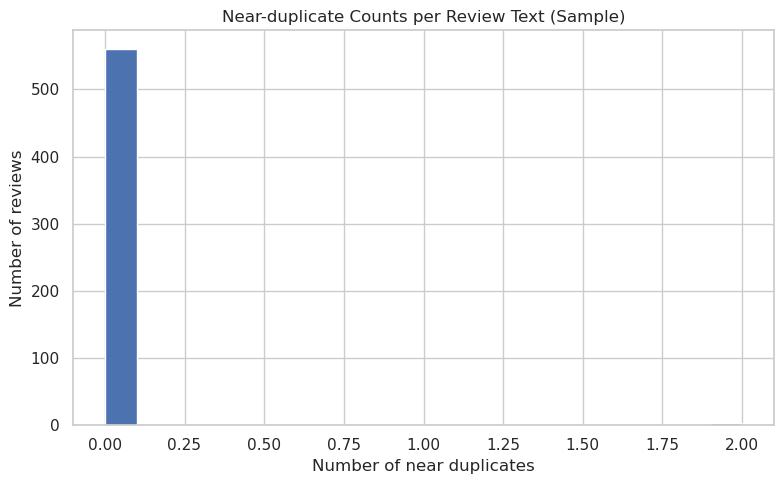

Texts in sample: 563
Texts with >=1 near-duplicate: 3 (0.53%)


In [4]:
%matplotlib inline

pdf_text_dup = text_dup_stats.toPandas()

plt.figure(figsize=(8,5))
plt.hist(pdf_text_dup["num_text_dups"], bins=20)
plt.title("Near-duplicate Counts per Review Text (Sample)")
plt.xlabel("Number of near duplicates")
plt.ylabel("Number of reviews")
plt.tight_layout()
plt.show()

total = len(pdf_text_dup)
with_dups = (pdf_text_dup["num_text_dups"] > 0).sum()
print(f"Texts in sample: {total}")
print(f"Texts with >=1 near-duplicate: {with_dups} ({with_dups/total:.2%})")

In [7]:
top5_asins = [
    r["parent_asin"]
    for r in (
        text_dup_stats
        .groupBy("parent_asin")
        .count()
        .orderBy(F.desc("count"))
        .limit(5)
        .collect()
    )
]
print("Top 5 parent_asin:", top5_asins)

# 2) Filter to top 5 and compute duplication fraction
text_top5 = text_dup_stats.filter(F.col("parent_asin").isin(top5_asins))

pdf_top5_text = (
    text_top5
    .groupBy("parent_asin")
    .agg(
        F.count("*").alias("n_reviews"),
        F.sum(F.when(F.col("num_text_dups") > 0, 1).otherwise(0)).alias("n_reviews_with_dups")
    )
    .withColumn("dup_fraction", F.col("n_reviews_with_dups") / F.col("n_reviews"))
    .orderBy(F.desc("dup_fraction"))
    .toPandas()
)

pdf_top5_text

Top 5 parent_asin: ['B0042EEAAG', '0446581348', '1563923572', 'B005IQ3PS0', '0892878053']


,parent_asin,n_reviews,n_reviews_with_dups,dup_fraction
0,B0042EEAAG,80,3,0.0375
1,1563923572,45,0,0.0000
2,0446581348,57,0,0.0000
3,0892878053,30,0,0.0000
4,B005IQ3PS0,33,0,0.0000


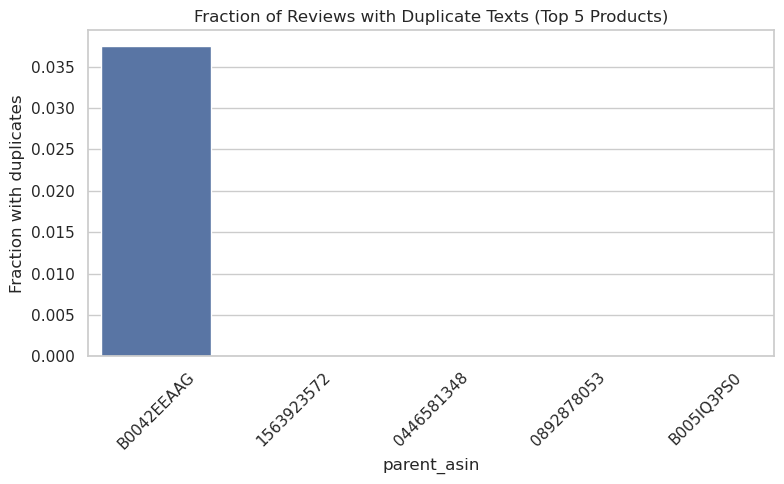

In [8]:
%matplotlib inline

plt.figure(figsize=(8,5))
sns.barplot(data=pdf_top5_text, x="parent_asin", y="dup_fraction")
plt.title("Fraction of Reviews with Duplicate Texts (Top 5 Products)")
plt.xlabel("parent_asin")
plt.ylabel("Fraction with duplicates")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()